# 09 - Comparaison U-Net vs baseline Canny classique

**Objectif :** comparer quantitativement le nouveau pipeline U-Net a l'ancienne
approche classique (Canny + OpenCV), sur 3 niveaux :

- **Partie A** - qualite de segmentation au niveau patch (IoU, Dice, temps)
  contre les masques annotes (verite terrain).
- **Partie B** - detection de pieces sur les tracés complets (comptage,
  dimensions en cm, conformite ±3cm) et temps d'execution de bout en bout.

**Important :** aucune baseline Canny n'existant deja dans le projet, ce
notebook la construit entierement (fonctions `canny_baseline_mask` /
`canny_detect_pieces`). Les parametres Canny (`low`, `high`) sont des valeurs
de depart raisonnables - a ajuster si les resultats semblent mauvais (section
1.2 permet de visualiser rapidement l'effet des seuils sur quelques
exemples avant de lancer la comparaison complete).

In [49]:
import sys
sys.path.append('../src/segmentation')

import json
import time
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import build_model
from dataset import PatchDataset, IMAGENET_MEAN, IMAGENET_STD

try:
    import fitz  # PyMuPDF
except ImportError:
    raise ImportError("PyMuPDF manquant. Installer avec : pip install pymupdf")

## 0. Configuration

In [50]:
PATCHES_DIR = '../data/processed/patches'
CHECKPOINTS_DIR = '../models/saved'
RESULTS_DIR = '../data/results'

TRACEES_PDF_DIR = '../data/raw/reference'

# A ADAPTER : chemin vers la table de conformite deja construite (Phase 2).
# Fichier absent chez toi pour l'instant -> la Partie B calculera quand meme
# le comptage/temps de detection, mais sautera le calcul d'erreur en cm et
# de conformite (avec un message clair a ce moment-la).
REFERENCE_TABLE_PATH = '../data/processed/reference_dimensions.json'

TOLERANCE_CM = 3.0        # tolerance de conformite du projet
CANNY_LOW = 50             # seuil bas de Canny - a ajuster selon section 1.2
CANNY_HIGH = 150           # seuil haut de Canny
DPI_RASTERISATION = 150    # resolution de rendu des PDFs (compromis vitesse/precision)

TRACEES = ["Tracee1", "Tracee2", "Tracee3", "Tracee4"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device : {DEVICE}")
print(f"Seuils Canny : low={CANNY_LOW}, high={CANNY_HIGH}")
print(f"DPI de rasterisation : {DPI_RASTERISATION} (echelle : {2.54/DPI_RASTERISATION:.4f} cm/pixel)")


Device : cuda
Seuils Canny : low=50, high=150
DPI de rasterisation : 150 (echelle : 0.0169 cm/pixel)


### 0.1 Detection automatique des fichiers PDF par tracé

Recherche insensible a la casse : trouve le fichier `.pdf` dont le nom contient "Tracee1", "Tracee2", etc. dans `TRACEES_PDF_DIR`. Pas besoin de connaitre les noms exacts a l'avance.

In [51]:
def find_pdf_for_tracee(tracee, pdf_dir=TRACEES_PDF_DIR):
    """Cherche dans pdf_dir un fichier .pdf dont le nom contient le nom du
    tracé (insensible a la casse). Retourne le Path ou None si absent."""
    pdf_dir = Path(pdf_dir)
    if not pdf_dir.exists():
        return None
    candidats = sorted(pdf_dir.glob("*.pdf"))
    for c in candidats:
        if tracee.lower() in c.stem.lower():
            return c
    return None


print(f"Contenu de {TRACEES_PDF_DIR} :")
if Path(TRACEES_PDF_DIR).exists():
    for f in sorted(Path(TRACEES_PDF_DIR).glob('*.pdf')):
        print(f"  - {f.name}")
else:
    print(f"  [ATTENTION] Dossier introuvable : {TRACEES_PDF_DIR}")

print("\nCorrespondance trouvee par tracé :")
for tracee in TRACEES:
    trouve = find_pdf_for_tracee(tracee)
    print(f"  {tracee:10s} -> {trouve.name if trouve else 'AUCUN FICHIER TROUVE'}")

Contenu de ../data/raw/reference :
  - Tracee1.pdf
  - Tracee2.pdf
  - Tracee3.pdf
  - Tracee4.pdf

Correspondance trouvee par tracé :
  Tracee1    -> Tracee1.pdf
  Tracee2    -> Tracee2.pdf
  Tracee3    -> Tracee3.pdf
  Tracee4    -> Tracee4.pdf


## 1. Partie A - Comparaison au niveau patch

### 1.1 Fonctions de base

In [52]:
def canny_baseline_mask(image_rgb, low=CANNY_LOW, high=CANNY_HIGH, dilate_iter=1):
    """Baseline Canny 'contour ferme rempli' - garde le plus grand contour
    ferme et le remplit. NE FONCTIONNE BIEN QUE SUR UNE IMAGE CONTENANT UNE
    PIECE ENTIERE (tracé complet, Partie B) : sur un patch recadre, les
    frontieres de pieces sont souvent des courbes ouvertes (coupees par le
    bord du crop), donc aucun contour ferme correct n'existe et l'heuristique
    se rabat a tort sur de petits symboles/etiquettes fermes. A ne PAS
    utiliser pour comparer au niveau patch (voir canny_edges ci-dessous)."""
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, low, high)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=dilate_iter)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros(gray.shape, dtype=np.uint8)
    if contours:
        plus_grand = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [plus_grand], -1, 255, thickness=cv2.FILLED)
    return mask


def canny_edges(image_rgb, low=CANNY_LOW, high=CANNY_HIGH, dilate_iter=1):
    """Detection d'edges Canny BRUTS (pas de remplissage, pas besoin de
    contour ferme). Comparable equitablement au canal 'frontiere' du dataset
    annote, meme sur un patch recadre ou les frontieres sont partielles.
    Une legere dilatation tolere un desalignement de quelques pixels entre
    le trait Canny et l'annotation (pratique standard en evaluation de
    contours)."""
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, low, high)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=dilate_iter)
    return edges


def iou_dice(mask_pred, mask_true, thresh=127):
    """IoU et Dice entre deux masques binaires (0/255 ou 0/1)."""
    p = (mask_pred > thresh).astype(np.uint8)
    t = (mask_true > thresh).astype(np.uint8)
    intersection = int((p & t).sum())
    union = int((p | t).sum())
    iou = intersection / union if union > 0 else 1.0
    somme = int(p.sum() + t.sum())
    dice = 2 * intersection / somme if somme > 0 else 1.0
    return iou, dice


def unet_edges_from_mask(mask_unet, dilate_iter=1):
    """Extrait les contours du masque predit par U-Net (canal interieur),
    pour une comparaison equitable avec canny_edges sur le meme canal
    'frontiere' - les deux methodes sont alors evaluees sur la meme tache
    (localiser la frontiere), pas sur le remplissage de zone."""
    contours, _ = cv2.findContours(mask_unet, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    edges = np.zeros_like(mask_unet)
    cv2.drawContours(edges, contours, -1, 255, thickness=1)
    if dilate_iter > 0:
        edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=dilate_iter)
    return edges


def unet_predict_mask(model, image_tensor, threshold=0.5):
    """Prediction U-Net pour un patch deja normalise (tensor CHW).
    Retourne le masque du canal 'interieur' (index 0), binaire 0/255."""
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
    return (probs > threshold).astype(np.uint8) * 255


### 1.2 Verification visuelle rapide des seuils Canny

A regarder avant de lancer la comparaison complete : si le masque Canny est
tres bruite (plein de petits fragments) ou au contraire vide, ajuster
`CANNY_LOW`/`CANNY_HIGH` dans la config et relancer cette cellule.

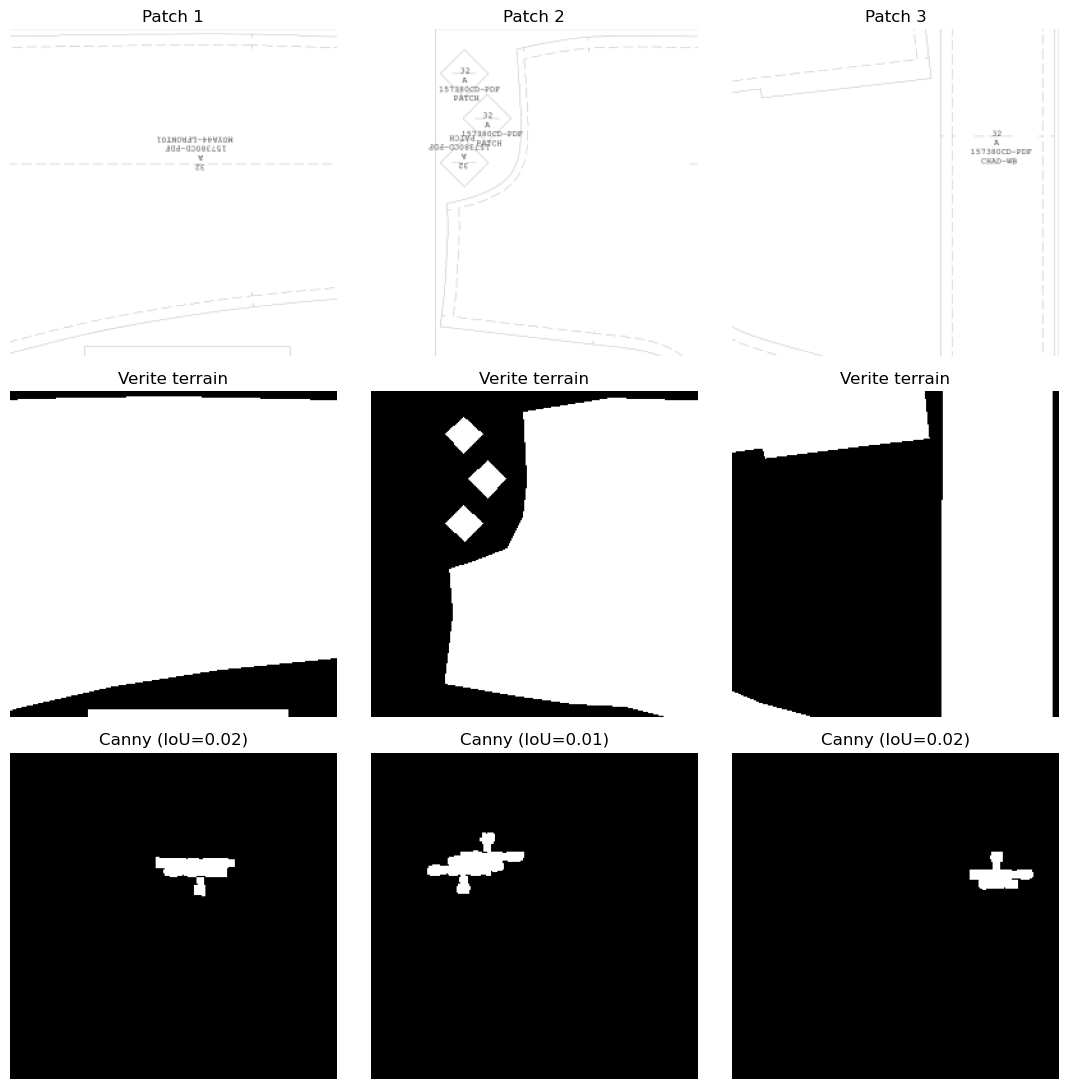

In [53]:
ds_apercu = PatchDataset(PATCHES_DIR, include_tracees=[TRACEES[0]])

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for col in range(3):
    image_path = ds_apercu.samples[col]
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    base = str(image_path).replace("_image.png", "")
    mask_true = cv2.imread(base + "_interieur.png", cv2.IMREAD_GRAYSCALE)
    mask_canny = canny_baseline_mask(image_rgb)
    iou, dice = iou_dice(mask_canny, mask_true)

    axes[0, col].imshow(image_rgb); axes[0, col].set_title(f"Patch {col+1}"); axes[0, col].axis("off")
    axes[1, col].imshow(mask_true, cmap="gray"); axes[1, col].set_title("Verite terrain"); axes[1, col].axis("off")
    axes[2, col].imshow(mask_canny, cmap="gray"); axes[2, col].set_title(f"Canny (IoU={iou:.2f})"); axes[2, col].axis("off")

plt.tight_layout()
plt.show()

### 1.3 Comparaison complete Canny vs U-Net sur tous les patchs

Pour chaque tracé, on utilise le checkpoint U-Net entraine SANS ce tracé
(`unet_fold_{tracee}_best.pt`) - coherent avec la validation
leave-one-tracé-out deja faite, aucune fuite de donnees.

In [54]:
resultats_patch = []

for tracee in TRACEES:
    checkpoint_path = Path(CHECKPOINTS_DIR) / f"unet_fold_{tracee}_best.pt"
    if not checkpoint_path.exists():
        print(f"[ATTENTION] Checkpoint manquant pour {tracee}, ignore : {checkpoint_path}")
        continue

    model = build_model(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    ds = PatchDataset(PATCHES_DIR, include_tracees=[tracee])
    print(f"{tracee} : {len(ds)} patchs...")

    for i in range(len(ds)):
        image_path = ds.samples[i]
        image_bgr = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        base = str(image_path).replace("_image.png", "")
        mask_true_interieur = cv2.imread(base + "_interieur.png", cv2.IMREAD_GRAYSCALE)
        mask_true_frontiere = cv2.imread(base + "_frontiere.png", cv2.IMREAD_GRAYSCALE)

        # --- U-Net vs canal INTERIEUR : comparaison directe, non biaisee
        # (U-Net predit directement une zone remplie, pas de probleme de
        # fermeture de contour comme pour Canny) - metrique la PLUS fiable
        # de la qualite de segmentation U-Net au niveau patch ---
        image_t, _ = ds[i]
        t0 = time.time()
        mask_unet = unet_predict_mask(model, image_t)
        t_unet = time.time() - t0
        iou_u_interieur, dice_u_interieur = iou_dice(mask_unet, mask_true_interieur)

        # --- Comparaison EQUITABLE Canny/U-Net : edges bruts vs canal
        # 'frontiere' (pas besoin de contour ferme, valable meme sur un crop
        # partiel) ---
        t0 = time.time()
        edges_canny = canny_edges(image_rgb)
        t_canny = time.time() - t0
        iou_c_frontiere, dice_c_frontiere = iou_dice(edges_canny, mask_true_frontiere)

        edges_unet = unet_edges_from_mask(mask_unet)
        iou_u_frontiere, dice_u_frontiere = iou_dice(edges_unet, mask_true_frontiere)

        # --- Ancienne comparaison Canny (remplissage) conservee a titre
        # indicatif uniquement, connue pour etre biaisee au niveau patch
        # (voir discussion section 1.2/1.3) - ne pas utiliser comme metrique
        # principale ---
        mask_canny_rempli = canny_baseline_mask(image_rgb)
        iou_c_rempli, dice_c_rempli = iou_dice(mask_canny_rempli, mask_true_interieur)

        resultats_patch.append({
            "tracee": tracee, "patch": image_path.name,
            "iou_unet_interieur": iou_u_interieur, "dice_unet_interieur": dice_u_interieur,
            "iou_canny_frontiere": iou_c_frontiere, "dice_canny_frontiere": dice_c_frontiere,
            "iou_unet_frontiere": iou_u_frontiere, "dice_unet_frontiere": dice_u_frontiere,
            "temps_canny_s": t_canny, "temps_unet_s": t_unet,
            "iou_canny_rempli_biaise": iou_c_rempli, "dice_canny_rempli_biaise": dice_c_rempli,
        })

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"\n{len(resultats_patch)} patchs compares au total.")


Tracee1 : 140 patchs...
Tracee2 : 200 patchs...
Tracee3 : 132 patchs...
Tracee4 : 188 patchs...

660 patchs compares au total.


In [55]:
def moyenne(cle):
    return float(np.mean([r[cle] for r in resultats_patch]))

print("="*70)
print("RESUME PARTIE A - comparaison au niveau patch")
print("="*70)
print("\n1) U-Net vs canal INTERIEUR (comparaison directe, non biaisee) :")
print(f"   IoU moyen  = {moyenne('iou_unet_interieur'):.4f}")
print(f"   Dice moyen = {moyenne('dice_unet_interieur'):.4f}")

print("\n2) Canny vs U-Net sur canal FRONTIERE (comparaison equitable, edges) :")
print(f"   {'Metrique':22s} {'Canny':>10s} {'U-Net':>10s}")
print(f"   {'IoU moyen':22s} {moyenne('iou_canny_frontiere'):10.4f} {moyenne('iou_unet_frontiere'):10.4f}")
print(f"   {'Dice moyen':22s} {moyenne('dice_canny_frontiere'):10.4f} {moyenne('dice_unet_frontiere'):10.4f}")
print(f"   {'Temps/patch (ms)':22s} {moyenne('temps_canny_s')*1000:10.2f} {moyenne('temps_unet_s')*1000:10.2f}")

print(f"\n[Pour reference uniquement, NE PAS interpreter comme resultat principal]")
print(f"IoU Canny (remplissage, biaise au niveau patch) : {moyenne('iou_canny_rempli_biaise'):.4f}")

resume_partie_a = {
    "iou_unet_interieur_moyen": moyenne("iou_unet_interieur"),
    "dice_unet_interieur_moyen": moyenne("dice_unet_interieur"),
    "iou_canny_frontiere_moyen": moyenne("iou_canny_frontiere"), "iou_unet_frontiere_moyen": moyenne("iou_unet_frontiere"),
    "dice_canny_frontiere_moyen": moyenne("dice_canny_frontiere"), "dice_unet_frontiere_moyen": moyenne("dice_unet_frontiere"),
    "temps_canny_ms_moyen": moyenne("temps_canny_s") * 1000,
    "temps_unet_ms_moyen": moyenne("temps_unet_s") * 1000,
}


RESUME PARTIE A - comparaison au niveau patch

1) U-Net vs canal INTERIEUR (comparaison directe, non biaisee) :
   IoU moyen  = 0.9138
   Dice moyen = 0.9518

2) Canny vs U-Net sur canal FRONTIERE (comparaison equitable, edges) :
   Metrique                    Canny      U-Net
   IoU moyen                  0.0533     0.2044
   Dice moyen                 0.0860     0.3339
   Temps/patch (ms)             0.44      10.41

[Pour reference uniquement, NE PAS interpreter comme resultat principal]
IoU Canny (remplissage, biaise au niveau patch) : 0.0212


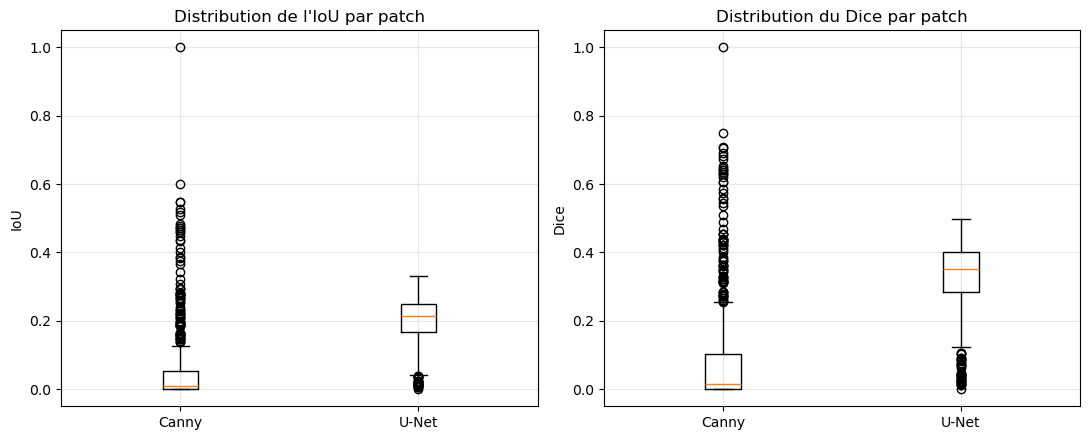

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].boxplot([[r["iou_canny_frontiere"] for r in resultats_patch], [r["iou_unet_frontiere"] for r in resultats_patch]],
                tick_labels=["Canny", "U-Net"])
axes[0].set_title("Distribution de l'IoU par patch")
axes[0].set_ylabel("IoU")
axes[0].grid(alpha=0.3)

axes[1].boxplot([[r["dice_canny_frontiere"] for r in resultats_patch], [r["dice_unet_frontiere"] for r in resultats_patch]],
                tick_labels=["Canny", "U-Net"])
axes[1].set_title("Distribution du Dice par patch")
axes[1].set_ylabel("Dice")
axes[1].grid(alpha=0.3)

plt.tight_layout()
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(Path(RESULTS_DIR) / "comparaison_canny_unet_patch.png", dpi=120)
plt.show()

## 2. Partie B - Comparaison au niveau tracé complet

### 2.1 Rasterisation des PDFs a l'echelle 1:1 connue

Les PDFs sont deja vectoriels a l'echelle 1:1 (voir contexte du projet) - le
facteur de conversion pixel -> cm est donc connu directement a partir du DPI
de rendu choisi, sans calibration.

In [57]:
# Chemins vers les fichiers deja construits dans les phases precedentes
# du projet - contiennent l'echelle EXACTE (calibree par carte physique,
# pas un DPI generique) et la taille de rendu utilisee pour extraire les
# patchs d'entrainement. Plus de calibration par tatonnement necessaire.
ANNOTATIONS_DIR = '../data/processed'
BASELINE_BENCHMARK_PATH = '../data/results/01_baseline_benchmark.json'

with open(BASELINE_BENCHMARK_PATH) as f:
    baseline_benchmark = json.load(f)

infos_echelle_tracee = {}
for tracee in TRACEES:
    with open(f"{ANNOTATIONS_DIR}/{tracee}_annotations.json") as f:
        annot = json.load(f)
    bench = baseline_benchmark[tracee]
    w_px, h_px = annot["image_original_size_px"]
    w_cm, h_cm = bench["taille_physique_reelle_cm"]
    scale_cm_par_px = ((w_cm / w_px) + (h_cm / h_px)) / 2  # moyenne des 2 axes
    infos_echelle_tracee[tracee] = {
        "target_w_px": w_px, "target_h_px": h_px,
        "scale_cm_par_px": scale_cm_par_px,
        "n_pieces_annotees": len(annot["pieces"]),
        "pieces_reelles_ancien_baseline": bench.get("pieces_reelles_texte"),
        "pieces_detectees_ancien_baseline": bench.get("pieces_detectees_baseline"),
    }
    print(f"{tracee}: cible={w_px}x{h_px}px | echelle={scale_cm_par_px:.5f} cm/px | "
          f"n_pieces_annotees={infos_echelle_tracee[tracee]['n_pieces_annotees']} | "
          f"ancien_baseline_detectees={infos_echelle_tracee[tracee]['pieces_detectees_ancien_baseline']}")


def render_page_matching_original(pdf_path, target_w_px, target_h_px, page_number=0):
    """Calcule le zoom exact necessaire pour rasteriser la page a (quasiment)
    la taille cible directement, sans sur-echantillonner puis reduire (evite
    l'erreur 'Overly large image' de PyMuPDF sur les grands traces physiques,
    ex. 200+ cm de long a haute resolution)."""
    doc = fitz.open(pdf_path)
    page = doc[page_number]
    page_w_pt, page_h_pt = page.rect.width, page.rect.height

    zoom_x = target_w_px / page_w_pt
    zoom_y = target_h_px / page_h_pt
    mat = fitz.Matrix(zoom_x, zoom_y)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if pix.n == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    doc.close()

    # ajustement fin si arrondi de pixels legerement different de la cible
    if img.shape[1] != target_w_px or img.shape[0] != target_h_px:
        img = cv2.resize(img, (target_w_px, target_h_px), interpolation=cv2.INTER_AREA)
    return img


Tracee1: cible=4000x2478px | echelle=0.05070 cm/px | n_pieces_annotees=25 | ancien_baseline_detectees=18
Tracee2: cible=4000x2417px | echelle=0.06300 cm/px | n_pieces_annotees=40 | ancien_baseline_detectees=70
Tracee3: cible=3196x4000px | echelle=0.04016 cm/px | n_pieces_annotees=23 | ancien_baseline_detectees=33
Tracee4: cible=3965x4000px | echelle=0.03716 cm/px | n_pieces_annotees=37 | ancien_baseline_detectees=66


### 2.2 Detection de pieces - Canny (tracé complet)

In [58]:
def canny_detect_pieces(image_rgb, scale_cm_par_px, low=CANNY_LOW, high=CANNY_HIGH,
                         min_area_cm2=10.0):
    """Detecte les pieces sur un tracé complet. Les frontieres de pieces
    etant souvent COLLEES entre elles (plan de decoupe imbrique/nesting,
    pratique standard pour minimiser les chutes), une simple recherche de
    contours fermes (findContours+RETR_EXTERNAL) echoue : tout le maillage
    de lignes connectees ne forme qu'UN SEUL contour externe. On utilise a
    la place les lignes comme des BARRIERES et on labellise par composantes
    connexes chaque region enfermee entre elles - approche correcte pour un
    maillage de pieces adjacentes.
    min_area_cm2 est un seuil de surface REEL (invariant a l'echelle)."""
    min_area_px = min_area_cm2 / (scale_cm_par_px ** 2)

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, low, high)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)

    # inverse : les lignes deviennent des barrieres noires, les regions
    # enfermees entre elles deviennent des blobs blancs distincts
    non_edges = cv2.bitwise_not(edges)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(non_edges, connectivity=4)

    # le plus grand composant est presque toujours la marge/fond exterieur
    # autour du plan de decoupe (visible dans l'aperçu diagnostic) - on
    # l'exclut d'office, peu importe sa position
    if n_labels <= 1:
        return []
    aires = stats[1:, cv2.CC_STAT_AREA]  # ignore le label 0 (fond du connectedComponents lui-meme)
    idx_fond = 1 + int(np.argmax(aires))

    pieces = []
    for label in range(1, n_labels):
        if label == idx_fond:
            continue
        aire = stats[label, cv2.CC_STAT_AREA]
        if aire < min_area_px:
            continue
        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]
        w = stats[label, cv2.CC_STAT_WIDTH]
        h = stats[label, cv2.CC_STAT_HEIGHT]
        pieces.append({"bbox_px": (x, y, w, h), "largeur_px": w, "hauteur_px": h, "aire_px": int(aire)})
    return pieces


### 2.3 Detection de pieces - U-Net (tracé complet, par tuiles 256x256)

In [59]:
def unet_predict_full_image(model, image_rgb, patch_size=256, stride=128):
    """Inference par tuiles CHEVAUCHANTES (stride < patch_size, 50% de
    recouvrement par defaut) avec moyenne des probabilites dans les zones
    de recouvrement, avant binarisation finale. Evite les artefacts de
    bordure de tuile qui deformaient les dimensions des pieces coupees pile
    a la frontiere entre deux tuiles non chevauchantes (cause probable de
    la faible conformite dimensionnelle observee malgre un bon IoU par
    patch)."""
    h, w, _ = image_rgb.shape
    prob_accum = np.zeros((h, w), dtype=np.float32)
    count_accum = np.zeros((h, w), dtype=np.float32)
    mean = IMAGENET_MEAN.numpy().reshape(1, 1, 3)
    std = IMAGENET_STD.numpy().reshape(1, 1, 3)

    ys = list(range(0, max(h - patch_size, 0) + 1, stride)) or [0]
    xs = list(range(0, max(w - patch_size, 0) + 1, stride)) or [0]
    if ys[-1] != max(h - patch_size, 0):
        ys.append(max(h - patch_size, 0))
    if xs[-1] != max(w - patch_size, 0):
        xs.append(max(w - patch_size, 0))

    for y in ys:
        for x in xs:
            patch = image_rgb[y:y + patch_size, x:x + patch_size]
            ph, pw = patch.shape[:2]
            if ph < patch_size or pw < patch_size:
                padded = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
                padded[:ph, :pw] = patch
                patch = padded
            patch_norm = (patch.astype(np.float32) / 255.0 - mean) / std
            tensor = torch.from_numpy(patch_norm).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = model(tensor)
                probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
            prob_accum[y:y + ph, x:x + pw] += probs[:ph, :pw]
            count_accum[y:y + ph, x:x + pw] += 1.0

    count_accum[count_accum == 0] = 1.0
    prob_moyenne = prob_accum / count_accum
    mask_full = (prob_moyenne > 0.5).astype(np.uint8) * 255
    return mask_full


def unet_detect_pieces(mask_full, scale_cm_par_px, min_area_cm2=10.0, closing_kernel_px=0):
    """Meme logique d'extraction de contours que Canny (meme seuil en cm2),
    appliquee au masque U-Net recompose. Une fermeture morphologique
    (dilatation puis erosion) est appliquee avant l'extraction pour recoller
    les fines discontinuites qui fragmentent parfois une meme piece reelle
    en plusieurs blobs distincts (cause probable de la sur-detection et de
    la mauvaise precision dimensionnelle observees) - sans fusionner de
    vraies pieces distinctes, separees par des traits bien plus larges que
    closing_kernel_px.

    ATTENTION - hypothese testee et REJETEE : la fermeture morphologique
    degrade les resultats plutot que de les ameliorer, quelle que soit la
    taille du noyau testee :
      - kernel=7px : fusionne TOUT le plan en un seul blob (les pieces sont
        collees entre elles - plan imbrique/nesting - meme piege que le bug
        initial de findContours+RETR_EXTERNAL sur ce type d'image)
      - kernel=3px : degrade aussi la conformite (44-63% contre 60-76% SANS
        fermeture) - meme un noyau modeste deforme legerement les bounding
        boxes, ce qui coute plus cher en precision que ce que le recollement
        de fragments apporte.
    Valeur par defaut (0 = desactivee) conservee comme la meilleure config
    trouvee a ce jour. Le residu de sur-comptage (pieces fragmentees) reste
    un axe d'amelioration possible mais PAS via une fermeture morphologique
    globale - une piste plus fine (fermeture uniquement le long des
    contours suspects, ou un seuil de probabilite adaptatif) serait
    necessaire, hors scope de ce notebook."""
    min_area_px = min_area_cm2 / (scale_cm_par_px ** 2)
    if closing_kernel_px > 0:
        kernel = np.ones((closing_kernel_px, closing_kernel_px), np.uint8)
        mask_full = cv2.morphologyEx(mask_full, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pieces = []
    for c in contours:
        aire = cv2.contourArea(c)
        if aire < min_area_px:
            continue
        x, y, w, h = cv2.boundingRect(c)
        pieces.append({"bbox_px": (x, y, w, h), "largeur_px": w, "hauteur_px": h, "aire_px": int(aire)})
    return pieces


### 2.4 Chargement de la table de conformite (si disponible)

Si `REFERENCE_TABLE_PATH` (defini section 0) ne correspond pas a
l'emplacement reel de ta table de conformite, ajuste le chemin puis relance
cette cellule. Sans ce fichier, la suite calcule quand meme le comptage de
pieces et le temps d'execution, mais saute le calcul d'erreur en cm et de
conformite.

In [60]:
reference_disponible = Path(REFERENCE_TABLE_PATH).exists()

dimensions_reference_par_tracee = {}

if reference_disponible:
    with open(REFERENCE_TABLE_PATH) as f:
        table_reference_brute = json.load(f)
    print(f"Table de reference chargee : {REFERENCE_TABLE_PATH}")

    # Format reel : {Tracee: {code_modele:.., pieces: {nom_piece: {largeur_cm, hauteur_cm, n_instances, ...}}}}
    # Chaque type de piece est reproduit n_instances fois - donne la liste
    # des instances physiques REELLEMENT attendues (pas juste les types
    # uniques), necessaire pour un appariement un-a-un correct.
    for tracee in TRACEES:
        if tracee not in table_reference_brute:
            dimensions_reference_par_tracee[tracee] = []
            continue
        pieces_ref = table_reference_brute[tracee]["pieces"]
        dims = []
        for p in pieces_ref.values():
            dims.extend([(p["largeur_cm"], p["hauteur_cm"])] * p.get("n_instances", 1))
        dimensions_reference_par_tracee[tracee] = dims
        print(f"  {tracee} : {len(pieces_ref)} types de pieces, "
              f"{len(dims)} instances physiques attendues (vs {infos_echelle_tracee[tracee]['n_pieces_annotees']} annotees)")
else:
    print(f"[INFO] Table de reference introuvable a {REFERENCE_TABLE_PATH}.")
    print("Le comptage de pieces et le temps d'execution seront quand meme calcules.")
    print("Ajuste REFERENCE_TABLE_PATH (section 0) si le fichier existe ailleurs, "
          "pour obtenir aussi l'erreur en cm et le taux de conformite.")


Table de reference chargee : ../data/processed/reference_dimensions.json
  Tracee1 : 15 types de pieces, 25 instances physiques attendues (vs 25 annotees)
  Tracee2 : 14 types de pieces, 40 instances physiques attendues (vs 40 annotees)
  Tracee3 : 14 types de pieces, 23 instances physiques attendues (vs 23 annotees)
  Tracee4 : 24 types de pieces, 37 instances physiques attendues (vs 37 annotees)


### 2.1bis Diagnostic visuel - pourquoi Canny s'effondre sur certains traces

A executer avant la section 2.5 si les comptages Canny semblent casses
(ex. 1 seule piece detectee). Affiche l'image rasterisee, la carte d'edges
Canny brute, et le nombre de contours EXTERNES trouves - permet de voir si
les traits sont bien detectes mais fusionnes, ou s'ils sont simplement
absents (contraste/seuils inadaptes a cette echelle).

Tracee2 : 72 pieces detectees par composantes connexes (vs 40 annotees, 70 pour l'ancien systeme)


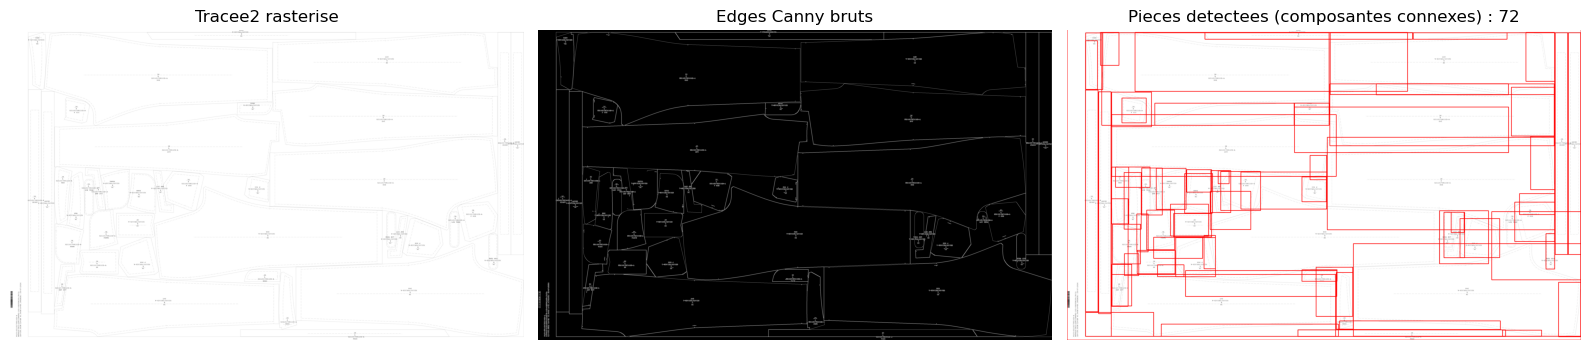

In [61]:
TRACEE_DIAGNOSTIC = "Tracee2"  # change pour Tracee3 / Tracee4 si besoin

pdf_path_diag = find_pdf_for_tracee(TRACEE_DIAGNOSTIC)
infos_diag = infos_echelle_tracee[TRACEE_DIAGNOSTIC]
image_diag = render_page_matching_original(
    pdf_path_diag, infos_diag["target_w_px"], infos_diag["target_h_px"]
)
scale_diag = infos_diag["scale_cm_par_px"]

gray_diag = cv2.cvtColor(image_diag, cv2.COLOR_RGB2GRAY)
blurred_diag = cv2.GaussianBlur(gray_diag, (5, 5), 0)
edges_diag = cv2.Canny(blurred_diag, CANNY_LOW, CANNY_HIGH)
edges_dilated_diag = cv2.dilate(edges_diag, np.ones((3, 3), np.uint8), iterations=1)

pieces_diag = canny_detect_pieces(image_diag, scale_diag)
print(f"{TRACEE_DIAGNOSTIC} : {len(pieces_diag)} pieces detectees par composantes connexes "
      f"(vs {infos_diag['n_pieces_annotees']} annotees, {infos_diag['pieces_detectees_ancien_baseline']} "
      f"pour l'ancien systeme)")

# visualisation : dessiner un rectangle sur chaque piece detectee
image_annotee = image_diag.copy()
for p in pieces_diag:
    x, y, w, h = p["bbox_px"]
    cv2.rectangle(image_annotee, (x, y), (x + w, y + h), (255, 0, 0), 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(image_diag); axes[0].set_title(f"{TRACEE_DIAGNOSTIC} rasterise"); axes[0].axis("off")
axes[1].imshow(edges_diag, cmap="gray"); axes[1].set_title("Edges Canny bruts"); axes[1].axis("off")
axes[2].imshow(image_annotee); axes[2].set_title(f"Pieces detectees (composantes connexes) : {len(pieces_diag)}"); axes[2].axis("off")
plt.tight_layout()
plt.show()

### 2.5 Comparaison complete sur les 4 tracés

In [62]:
resultats_tracee = []

for tracee in TRACEES:
    pdf_path = find_pdf_for_tracee(tracee)
    if pdf_path is None:
        print(f"[ATTENTION] PDF introuvable pour {tracee}, ignore.")
        continue

    checkpoint_path = Path(CHECKPOINTS_DIR) / f"unet_fold_{tracee}_best.pt"
    if not checkpoint_path.exists():
        print(f"[ATTENTION] Checkpoint manquant pour {tracee}, ignore : {checkpoint_path}")
        continue

    infos = infos_echelle_tracee[tracee]
    print(f"\n{tracee} (echelle={infos['scale_cm_par_px']:.5f} cm/px, "
          f"cible={infos['target_w_px']}x{infos['target_h_px']}px)...")

    image_rgb = render_page_matching_original(
        pdf_path, infos["target_w_px"], infos["target_h_px"]
    )
    scale_cm_par_px = infos["scale_cm_par_px"]

    # --- Canny ---
    t0 = time.time()
    pieces_canny = canny_detect_pieces(image_rgb, scale_cm_par_px)
    t_canny = time.time() - t0

    # --- U-Net ---
    model = build_model(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    t0 = time.time()
    mask_full = unet_predict_full_image(model, image_rgb)
    pieces_unet = unet_detect_pieces(mask_full, scale_cm_par_px)
    t_unet = time.time() - t0

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    resultats_tracee.append({
        "tracee": tracee,
        "n_pieces_annotees_verite": infos["n_pieces_annotees"],
        "n_pieces_ancien_baseline_canny": infos["pieces_detectees_ancien_baseline"],
        "n_pieces_canny": len(pieces_canny), "temps_canny_s": t_canny,
        "n_pieces_unet": len(pieces_unet), "temps_unet_s": t_unet,
        "scale_cm_par_px": scale_cm_par_px,
        "dimensions_canny_cm": [(w * scale_cm_par_px, h * scale_cm_par_px) for _, _, w, h in
                                 [p["bbox_px"] for p in pieces_canny]],
        "dimensions_unet_cm": [(w * scale_cm_par_px, h * scale_cm_par_px) for _, _, w, h in
                                [p["bbox_px"] for p in pieces_unet]],
    })
    print(f"  Verite terrain (annotee)       : {infos['n_pieces_annotees']} pieces")
    print(f"  Ancien systeme Canny (historique) : {infos['pieces_detectees_ancien_baseline']} pieces")
    print(f"  Notre Canny (nouveau)           : {len(pieces_canny)} pieces en {t_canny:.2f}s")
    print(f"  U-Net                          : {len(pieces_unet)} pieces en {t_unet:.2f}s")

print(f"\n{len(resultats_tracee)} traces compares.")



Tracee1 (echelle=0.05070 cm/px, cible=4000x2478px)...
  Verite terrain (annotee)       : 25 pieces
  Ancien systeme Canny (historique) : 18 pieces
  Notre Canny (nouveau)           : 15 pieces en 0.05s
  U-Net                          : 33 pieces en 5.71s

Tracee2 (echelle=0.06300 cm/px, cible=4000x2417px)...
  Verite terrain (annotee)       : 40 pieces
  Ancien systeme Canny (historique) : 70 pieces
  Notre Canny (nouveau)           : 72 pieces en 0.04s
  U-Net                          : 50 pieces en 5.22s

Tracee3 (echelle=0.04016 cm/px, cible=3196x4000px)...
  Verite terrain (annotee)       : 23 pieces
  Ancien systeme Canny (historique) : 33 pieces
  Notre Canny (nouveau)           : 41 pieces en 0.05s
  U-Net                          : 41 pieces en 6.81s

Tracee4 (echelle=0.03716 cm/px, cible=3965x4000px)...
  Verite terrain (annotee)       : 37 pieces
  Ancien systeme Canny (historique) : 66 pieces
  Notre Canny (nouveau)           : 69 pieces en 0.07s
  U-Net                   

### 2.6 Resume Partie B

**Comptage et temps** : toujours calcules. **Erreur en cm / conformite** :
uniquement si `table_reference` a pu etre chargee (section 2.4). Le format
attendu ici est simplifie (nombre total de pieces attendues par tracé et
liste de dimensions de reference) - adapte la fonction
`comparer_a_la_reference` ci-dessous a la structure exacte de ta table si
elle differe.

In [63]:
print("="*90)
print("RESUME PARTIE B - comptage de pieces (verite terrain vs ancien Canny vs nouveau vs U-Net)")
print("="*90)
print(f"{'Trace':10s} {'Verite':>8s} {'Ancien Canny':>13s} {'Nouv. Canny':>12s} {'U-Net':>8s} "
      f"{'Canny (s)':>10s} {'U-Net (s)':>10s}")
for r in resultats_tracee:
    print(f"{r['tracee']:10s} {r['n_pieces_annotees_verite']:8d} "
          f"{r['n_pieces_ancien_baseline_canny']:13d} {r['n_pieces_canny']:12d} {r['n_pieces_unet']:8d} "
          f"{r['temps_canny_s']:10.2f} {r['temps_unet_s']:10.2f}")

temps_canny_moyen = float(np.mean([r["temps_canny_s"] for r in resultats_tracee])) if resultats_tracee else None
temps_unet_moyen = float(np.mean([r["temps_unet_s"] for r in resultats_tracee])) if resultats_tracee else None
print(f"\nTemps moyen par trace complet : Canny={temps_canny_moyen:.2f}s | U-Net={temps_unet_moyen:.2f}s")

resume_partie_b = {
    "temps_canny_s_moyen": temps_canny_moyen,
    "temps_unet_s_moyen": temps_unet_moyen,
    "detail_par_tracee": resultats_tracee,
}


def comparer_a_la_reference_appariee(dimensions_detectees_cm, pieces_reference, tolerance_cm=TOLERANCE_CM):
    """Appariement UN-A-UN glouton entre pieces detectees et instances de
    reference reelles (chaque instance de reference n'est utilisee qu'une
    seule fois). Corrige le biais de la version precedente : les instances
    de reference jamais appariees (pieces manquees) comptent explicitement
    comme NON CONFORMES au denominateur, au lieu d'etre ignorees - et les
    detections parasites ne peuvent plus 'voler' un bon score en s'appariant
    a une reference deja utilisee par une meilleure correspondance."""
    n_ref = len(pieces_reference)
    n_det = len(dimensions_detectees_cm)
    if n_ref == 0:
        return {"erreur_cm_moyenne": None, "taux_conformite": None, "taux_detection": None,
                "n_apparies": 0, "n_reference": 0}
    if n_det == 0:
        return {"erreur_cm_moyenne": None, "taux_conformite": 0.0, "taux_detection": 0.0,
                "n_apparies": 0, "n_reference": n_ref}

    paires = []
    for i, (w_det, h_det) in enumerate(dimensions_detectees_cm):
        for j, (w_ref, h_ref) in enumerate(pieces_reference):
            cout = max(abs(w_det - w_ref), abs(h_det - h_ref))
            paires.append((cout, i, j))
    paires.sort(key=lambda x: x[0])

    detectees_utilisees, references_utilisees = set(), set()
    erreurs_appariees = []
    for cout, i, j in paires:
        if i in detectees_utilisees or j in references_utilisees:
            continue
        detectees_utilisees.add(i)
        references_utilisees.add(j)
        erreurs_appariees.append(cout)

    n_apparies = len(erreurs_appariees)
    n_conformes = sum(1 for e in erreurs_appariees if e <= tolerance_cm)

    return {
        "erreur_cm_moyenne": float(np.mean(erreurs_appariees)) if erreurs_appariees else None,
        "taux_conformite": n_conformes / n_ref,   # denominateur = TOUTES les pieces reelles attendues
        "taux_detection": n_apparies / n_ref,      # part des pieces reelles effectivement retrouvees
        "n_apparies": n_apparies,
        "n_reference": n_ref,
    }


if reference_disponible:
    print("\n" + "="*90)
    print("CONFORMITE ±3cm - appariement un-a-un (pieces manquees = non conformes)")
    print("="*90)
    for r in resultats_tracee:
        references_dims = dimensions_reference_par_tracee.get(r["tracee"], [])
        res_canny = comparer_a_la_reference_appariee(r["dimensions_canny_cm"], references_dims)
        res_unet = comparer_a_la_reference_appariee(r["dimensions_unet_cm"], references_dims)
        r["conformite_canny"] = res_canny
        r["conformite_unet"] = res_unet

        print(f"\n{r['tracee']} ({res_canny['n_reference']} pieces reelles attendues) :")
        print(f"  Canny -> detection {res_canny['taux_detection']*100:5.1f}% "
              f"({res_canny['n_apparies']}/{res_canny['n_reference']}) | "
              f"conformite {res_canny['taux_conformite']*100:5.1f}% | "
              f"erreur moy. (sur apparies) {res_canny['erreur_cm_moyenne']:.2f} cm")
        print(f"  U-Net -> detection {res_unet['taux_detection']*100:5.1f}% "
              f"({res_unet['n_apparies']}/{res_unet['n_reference']}) | "
              f"conformite {res_unet['taux_conformite']*100:5.1f}% | "
              f"erreur moy. (sur apparies) {res_unet['erreur_cm_moyenne']:.2f} cm")
else:
    print("\n[INFO] Erreur en cm / conformite non calculees (table de reference introuvable).")


RESUME PARTIE B - comptage de pieces (verite terrain vs ancien Canny vs nouveau vs U-Net)
Trace        Verite  Ancien Canny  Nouv. Canny    U-Net  Canny (s)  U-Net (s)
Tracee1          25            18           15       33       0.05       5.71
Tracee2          40            70           72       50       0.04       5.22
Tracee3          23            33           41       41       0.05       6.81
Tracee4          37            66           69       61       0.07       8.55

Temps moyen par trace complet : Canny=0.05s | U-Net=6.57s

CONFORMITE ±3cm - appariement un-a-un (pieces manquees = non conformes)

Tracee1 (25 pieces reelles attendues) :
  Canny -> detection  60.0% (15/25) | conformite  60.0% | erreur moy. (sur apparies) 0.42 cm
  U-Net -> detection 100.0% (25/25) | conformite  60.0% | erreur moy. (sur apparies) 4.38 cm

Tracee2 (40 pieces reelles attendues) :
  Canny -> detection 100.0% (40/40) | conformite  95.0% | erreur moy. (sur apparies) 1.21 cm
  U-Net -> detection 100.0%

## 3. Resume final - a copier dans le rapport PFE

In [64]:
resume_final = {
    "partie_a_niveau_patch": resume_partie_a,
    "partie_b_niveau_tracee": resume_partie_b,
    "reference_table_utilisee": reference_disponible,
}

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
with open(Path(RESULTS_DIR) / "comparaison_canny_unet.json", "w") as f:
    json.dump(resume_final, f, indent=2)

print("="*70)
print("RESUME GLOBAL - U-NET vs CANNY")
print("="*70)
print("\n1) U-Net vs canal INTERIEUR (comparaison directe, non biaisee) :")
print(f"   IoU moyen  = {resume_partie_a['iou_unet_interieur_moyen']:.4f}")
print(f"   Dice moyen = {resume_partie_a['dice_unet_interieur_moyen']:.4f}")
print("\n2) Canny vs U-Net sur canal FRONTIERE (comparaison equitable, edges) :")
print(f"   IoU moyen        : Canny={resume_partie_a['iou_canny_frontiere_moyen']:.4f} | "
      f"U-Net={resume_partie_a['iou_unet_frontiere_moyen']:.4f}")
print(f"   Dice moyen       : Canny={resume_partie_a['dice_canny_frontiere_moyen']:.4f} | "
      f"U-Net={resume_partie_a['dice_unet_frontiere_moyen']:.4f}")
print(f"   Temps/patch (ms) : Canny={resume_partie_a['temps_canny_ms_moyen']:.2f} | "
      f"U-Net={resume_partie_a['temps_unet_ms_moyen']:.2f}")
if resume_partie_b['temps_canny_s_moyen'] is not None:
    print(f"\nTemps/trace (s)  : Canny={resume_partie_b['temps_canny_s_moyen']:.2f} | "
          f"U-Net={resume_partie_b['temps_unet_s_moyen']:.2f}")

print(f"\nSauvegarde dans {RESULTS_DIR}/comparaison_canny_unet.json")


RESUME GLOBAL - U-NET vs CANNY

1) U-Net vs canal INTERIEUR (comparaison directe, non biaisee) :
   IoU moyen  = 0.9138
   Dice moyen = 0.9518

2) Canny vs U-Net sur canal FRONTIERE (comparaison equitable, edges) :
   IoU moyen        : Canny=0.0533 | U-Net=0.2044
   Dice moyen       : Canny=0.0860 | U-Net=0.3339
   Temps/patch (ms) : Canny=0.44 | U-Net=10.41

Temps/trace (s)  : Canny=0.05 | U-Net=6.57

Sauvegarde dans ../data/results/comparaison_canny_unet.json
